# Barquisimeto Weather Patterns (2015–2025)

This notebook is adapted from the Ann Arbor example and configured for **Barquisimeto, Venezuela**.

It will:
- Show the locations of the Barquisimeto weather stations on a map using **folium**.
- Load the daily temperature data for Barquisimeto.
- Compute record high and low temperatures for each day of the year over **2015–2024** (excluding Feb 29).
- Find **2025** days where the daily high or low breaks those records.
- Visualize the results using **matplotlib** in a style suitable for embedding in a dashboard (e.g., GitHub Pages).

> **Note:** Update the configuration cell below with the correct CSV filenames and station hash for Barquisimeto in your dataset.

In [4]:
# Configuration
CITY_NAME = "Barquisimeto, Venezuela"

# Paths for Barquisimeto data (relative to the project root)
STATION_META_CSV = "data/BinSize_d400.csv"  # optional: metadata file if you have station locations
BARQUISIMETO_STATION_HASH = "REPLACE_WITH_BARQUISIMETO_HASH"  # update to correct hash if using the map
DATA_CSV = "../data/barquisimeto_nasa_2015_2025.csv"  # NASAPower-style CSV with fecha, tmax_c, tmin_c

# Years for the analysis
BASELINE_START_YEAR = 2015
BASELINE_END_YEAR = 2024
OVERLAY_YEAR = 2025

# Output settings for dashboard embedding (e.g., GitHub Pages)
OUTPUT_DIR = "../docs"  # GitHub Pages commonly serves from the 'docs' folder
MAP_HTML_NAME = "barquisimeto_stations_map.html"
PLOT_PNG_NAME = "barquisimeto_temperature_records.png"

In [5]:
import os
import pandas as pd
import folium
import matplotlib.pyplot as plt
from calendar import month_abbr

%matplotlib inline

## Station locations map (Barquisimeto)

Use **folium** to render the station locations for Barquisimeto. Update the configuration cell above so that
`STATION_META_CSV` and `BARQUISIMETO_STATION_HASH` correctly identify your stations.

In [6]:
# Load station metadata
df_loc = pd.read_csv(STATION_META_CSV)

station_locations = df_loc[df_loc["hash"] == BARQUISIMETO_STATION_HASH]

if station_locations.empty:
    raise ValueError("No stations found for the configured BARQUISIMETO_STATION_HASH. Update the configuration cell.")

lons = station_locations["LONGITUDE"].tolist()
lats = station_locations["LATITUDE"].tolist()

# Center map on first station
my_map = folium.Map(location=[lats[0], lons[0]], height=500, zoom_start=9)
for lat, lon in zip(lats, lons):
    folium.Marker([lat, lon]).add_to(my_map)

my_map

FileNotFoundError: [Errno 2] No such file or directory: 'assets/BinSize_d400.csv'

### Export map for dashboard embedding

Save the folium map as a standalone HTML file which can be directly embedded or linked from a GitHub Pages dashboard.

In [7]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
map_path = os.path.join(OUTPUT_DIR, MAP_HTML_NAME)
my_map.save(map_path)
map_path

NameError: name 'my_map' is not defined

## Load and transform Barquisimeto temperature dataset

The NASAPower file already stores daily max/min temperatures in degrees Celsius as `tmax_c` and `tmin_c`.
We will parse the dates, derive helper columns, and remove leap day (Feb 29).

In [8]:
# Load the daily temperature data for Barquisimeto
df = pd.read_csv(DATA_CSV)
df.head()

,fecha,tmax_c,tmin_c
0,2015-01-01,30.83,19.68
1,2015-01-02,29.51,20.12
2,2015-01-03,30.20,18.70
3,2015-01-04,30.88,17.95
4,2015-01-05,31.14,19.08


In [9]:
# Parse dates and add helper columns
# NASAPower file columns: fecha (date), tmax_c (daily max °C), tmin_c (daily min °C)
df["Date"] = pd.to_datetime(df["fecha"])
df["Year"] = df["Date"].dt.year
df["Month_Day"] = df["Date"].dt.strftime("%m-%d")

# Drop Feb 29
df = df[df["Month_Day"] != "02-29"]

# Filter to the years we care about (baseline + overlay)
years_of_interest = list(range(BASELINE_START_YEAR, BASELINE_END_YEAR + 1)) + [OVERLAY_YEAR]
df = df[df["Year"].isin(years_of_interest)].copy()

# For convenience, keep only the columns we need
df = df[["Date", "Year", "Month_Day", "tmax_c", "tmin_c"]].copy()

len(df)

4015

## Aggregate to daily max and min across all stations

For each date, we compute the maximum and minimum temperature across all reporting stations in Barquisimeto.

In [10]:
# Maximum temperature per date (across any stations, if present)
# Here the NASAPower file already has one row per day, but we keep groupby for robustness.
daily_max = (
    df.groupby("Date")["tmax_c"]
    .max()
    .to_frame(name="TMAX")
    .reset_index()
)

# Minimum temperature per date
daily_min = (
    df.groupby("Date")["tmin_c"]
    .min()
    .to_frame(name="TMIN")
    .reset_index()
)

for d in (daily_max, daily_min):
    d["Year"] = d["Date"].dt.year
    d["Month_Day"] = d["Date"].dt.strftime("%m-%d")

daily_max.shape, daily_min.shape

((4015, 4), (4015, 4))

## Split baseline (2015–2024) and 2025, then compute records

- Compute the record high and low for each day-of-year over the baseline years.
- Extract overlay-year (2025) daily values and find days where 2025 breaks those records.

In [11]:
# Baseline period
baseline_mask_max = (daily_max["Year"] >= BASELINE_START_YEAR) & (daily_max["Year"] <= BASELINE_END_YEAR)
baseline_mask_min = (daily_min["Year"] >= BASELINE_START_YEAR) & (daily_min["Year"] <= BASELINE_END_YEAR)

max_baseline = daily_max[baseline_mask_max].copy()
min_baseline = daily_min[baseline_mask_min].copy()

# Overlay year only
max_overlay = daily_max[daily_max["Year"] == OVERLAY_YEAR].copy()
min_overlay = daily_min[daily_min["Year"] == OVERLAY_YEAR].copy()

# Record highs and lows for each month-day over baseline
record_high_baseline = (
    max_baseline.groupby("Month_Day")["TMAX"]
    .max()
    .to_frame(name="TMAX")
)

record_low_baseline = (
    min_baseline.groupby("Month_Day")["TMIN"]
    .min()
    .to_frame(name="TMIN")
)

# Overlay-year daily values indexed by Month_Day
max_overlay_series = max_overlay.set_index("Month_Day")["TMAX"]
min_overlay_series = min_overlay.set_index("Month_Day")["TMIN"]

len(record_high_baseline), len(record_low_baseline)

(365, 365)

## Identify overlay-year (2025) record-breaking days

We locate 2025 days where the high exceeds the baseline record high, or the low falls below the baseline record low.

In [12]:
record_breaking_highs_overlay = max_overlay_series[
    max_overlay_series > record_high_baseline["TMAX"]
]

record_breaking_lows_overlay = min_overlay_series[
    min_overlay_series < record_low_baseline["TMIN"]
]

len(record_breaking_highs_overlay), len(record_breaking_lows_overlay)

(24, 28)

## Visualization for dashboard embedding

We plot:
- A line for the baseline record high and record low for each day of the year.
- A shaded band between those two lines.
- Scatter points for overlay-year (2025) days that broke the high/low records.

The figure is styled cleanly so it can be exported as a PNG and embedded directly in a static dashboard (e.g., GitHub Pages).

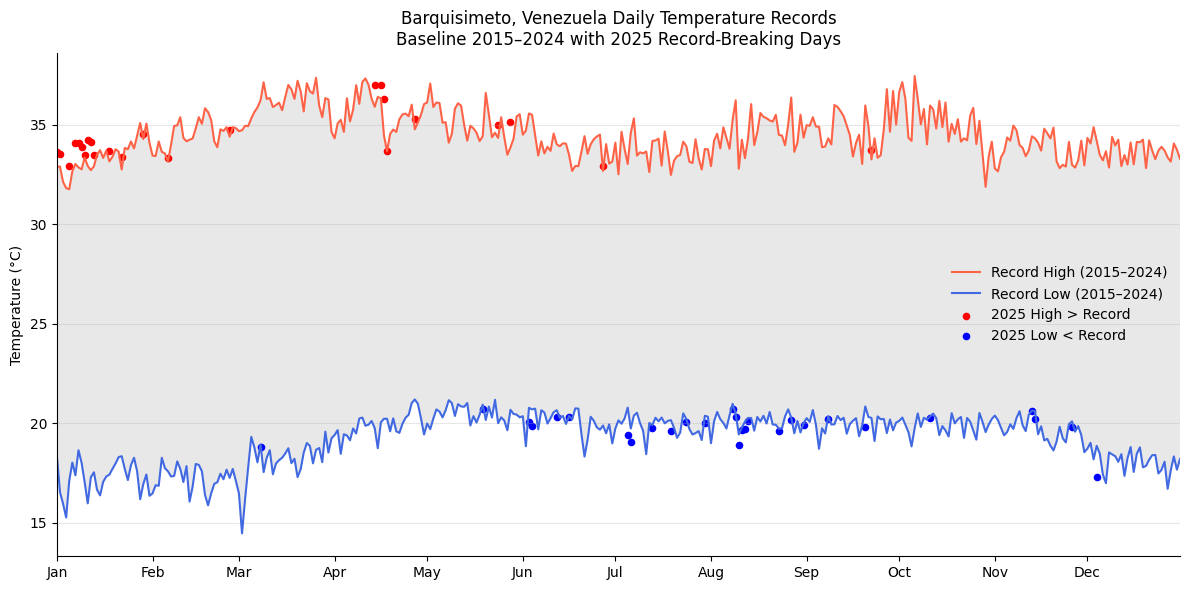

In [13]:
# Create a 365-day x-axis (non-leap year)
days = pd.date_range(f"{OVERLAY_YEAR}-01-01", f"{OVERLAY_YEAR}-12-31")
days = days[~((days.month == 2) & (days.day == 29))]

month_day_labels = days.strftime("%m-%d")
x = range(len(days))

# Align baseline series to this x-axis order
baseline_highs = record_high_baseline.loc[month_day_labels, "TMAX"].values
baseline_lows = record_low_baseline.loc[month_day_labels, "TMIN"].values

# Prepare overlay-year record-breaking points in x coordinates
md_list = list(month_day_labels)
high_break_x = [md_list.index(d) for d in record_breaking_highs_overlay.index]
high_break_y = record_breaking_highs_overlay.values

low_break_x = [md_list.index(d) for d in record_breaking_lows_overlay.index]
low_break_y = record_breaking_lows_overlay.values

fig, ax = plt.subplots(figsize=(12, 6))

# Record high and low lines
ax.plot(x, baseline_highs, '-', color='tomato', linewidth=1.5, label=f'Record High ({BASELINE_START_YEAR}–{BASELINE_END_YEAR})')
ax.plot(x, baseline_lows, '-', color='royalblue', linewidth=1.5, label=f'Record Low ({BASELINE_START_YEAR}–{BASELINE_END_YEAR})')

# Shaded area between record high and low
ax.fill_between(x, baseline_highs, baseline_lows, facecolor='lightgray', alpha=0.5)

# Overlay-year record-breaking points
ax.scatter(high_break_x, high_break_y, s=20, color='red', label=f'{OVERLAY_YEAR} High > Record')
ax.scatter(low_break_x, low_break_y, s=20, color='blue', label=f'{OVERLAY_YEAR} Low < Record')

# X-axis month labels (first day of each month)
month_starts = [i for i, d in enumerate(days) if d.day == 1]
month_labels = [month_abbr[d.month] for d in days if d.day == 1]

ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(0, len(x) - 1)

ax.set_ylabel('Temperature (°C)')
ax.set_title(f'{CITY_NAME} Daily Temperature Records\nBaseline {BASELINE_START_YEAR}–{BASELINE_END_YEAR} with {OVERLAY_YEAR} Record-Breaking Days')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)

# Remove chart junk (top/right spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Export figure for dashboard embedding

Save the plot as a PNG so it can be embedded in a GitHub Pages dashboard (for example by linking to it in HTML or Markdown).

In [14]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(OUTPUT_DIR, PLOT_PNG_NAME)
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plot_path

'docs/barquisimeto_temperature_records.png'